# Cosmic Microwave Background 2: Explore an all-sky map of the cosmic microwave background

## Authors
Nathaniel Starkman ([@nstarman](https://github.com/nstarman))

Adapted from the [*Coding the Cosmos* Cosmic Microwave Background workshop](https://github.com/Coding-the-Cosmos/notebooks/blob/05479e5b98aaa718cf43f931778a78aa61142c49/workshops/cmb.ipynb) by Louis Branch and Yilun Guan.

## Learning Goals
* Read an image and its world coordinate system (WCS) from a FITS file with `astropy.io.fits` and `astropy.wcs`
* Reproject an all-sky map onto a Mollweide projection in Galactic coordinates with `reproject`, and plot it with `astropy.visualization.wcsaxes`
* Measure the size of fluctuations in an image with `numpy` and a histogram
* Make cutouts of an image at positions on the sky with `astropy.coordinates.SkyCoord` and `astropy.nddata.Cutout2D`

## Keywords
FITS, wcs, coordinates, reproject, image analysis, histogram, matplotlib

## Companion Content
* [astropy.wcs documentation](https://docs.astropy.org/en/stable/wcs/)
* [Making plots with world coordinates (WCSAxes)](https://docs.astropy.org/en/stable/visualization/wcsaxes/)
* [reproject documentation](https://reproject.readthedocs.io)
* [Cosmic Microwave Background 1: Measure the temperature of the Universe from its blackbody spectrum](1_CMB-Blackbody-Temperature.ipynb)

## Summary
The temperature of the cosmic microwave background (CMB) is almost the same in every direction, but not quite. In this tutorial we will load a full-sky map of the CMB made by ESA's *Planck* satellite, plot it, and measure how large its temperature fluctuations are compared with the average temperature. We will then zoom in on one of the most famous features in the map, the CMB Cold Spot.

*Note: This is tutorial 2 of 3 in a series on the cosmic microwave background.*

## Imports

In [ ]:
%matplotlib inline
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.utils.data import download_file
from astropy.visualization.wcsaxes import SphericalCircle
from astropy.visualization.wcsaxes.frame import EllipticalFrame
from astropy.wcs import WCS
from reproject import reproject_interp

## Download and open the CMB map

The *Planck* satellite mapped the CMB over the whole sky between 2009 and 2013. Light from our own Galaxy also shines at microwave wavelengths, so the *Planck* team used the many frequencies that *Planck* observed to separate the CMB from everything else. We use the CMB map made by one of those methods, called Commander ([Planck Collaboration 2016](https://ui.adsabs.harvard.edu/abs/2016A%26A...594A...9P)), from the [Planck Legacy Archive](https://pla.esac.esa.int). We download the version of this map made for the *Coding the Cosmos* workshop, which was converted from *Planck*'s own format (a HEALPix map in Galactic coordinates) to an image in equatorial coordinates with 8-arcminute pixels, so that the file is a manageable 29 MB.

In [ ]:
# TODO: replace with the Zenodo record for this tutorial series
cmb_url = (
    "https://raw.githubusercontent.com/Coding-the-Cosmos/notebooks/"
    "05479e5b98aaa718cf43f931778a78aa61142c49/data/"
    "COM_CMB_IQU-commander_1024_R2.02_dg16_car.fits"
)
cmb_file = download_file(cmb_url, cache=True)

The file is a FITS file with a single image. We look at its header, which describes the image:

In [ ]:
cmb_header = fits.getheader(cmb_file)
print(repr(cmb_header))

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                 2700                                                  
NAXIS2  =                 1350                                                  
NAXIS3  =                    1                                                  
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =               1350.5 / Pixel coordinate of reference point            
CRPIX2  =            675.53125 / Pixel coordinate of reference point            
CDELT1  =    -0.13333333333333 / [deg] Coordinate increment at reference point  
CDELT2  =     0.13333333333333 / [deg] Coordinate increment at reference point  
CUNIT1  = 'deg'                / Units of coordinate increment and value        
CUNIT2  = 'deg'             

The header tells us that the image is 2700 by 1350 pixels, and how each pixel corresponds to a position on the sky. This mapping is the image's world coordinate system (WCS). The `CTYPE` keywords say that the two axes are right ascension (RA) and declination (Dec), the longitude and latitude of the equatorial coordinate system, in a "plate carrée" projection (`CAR`): each pixel covers the same range of RA and Dec, 0.133 degrees (8 arcminutes) on a side.

The image has a third axis of length 1, which holds a single temperature map. We read the WCS from the header. The `.celestial` attribute keeps only the two sky axes of the WCS.

In [ ]:
cmb_wcs = WCS(cmb_header).celestial
print(cmb_wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---CAR' 'DEC--CAR'
CUNIT : 'deg' 'deg'
CRVAL : 0.0041666666666667 0.0
CRPIX : 1350.5 675.53125
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -0.13333333333333 0.13333333333333
NAXIS : 2700  1350


Next we read the map itself, which is the first (and only) image along the third axis. Its values are the differences, in kelvin, between the temperature of the CMB in each direction and its average temperature. These differences are tiny, so we convert them to microkelvin (μK):

In [ ]:
cmb_map = (fits.getdata(cmb_file)[0] * u.K).to(u.uK)
print(cmb_map.shape)

temperature_label = f"Temperature difference [{cmb_map.unit:latex}]"

(1350, 2700)


## Plot the full sky

Plotting the image as it is stored would stretch the regions near the celestial poles sideways, much like Antarctica and Greenland look too large on many maps of the Earth. Maps of the whole sky are usually drawn with the Mollweide projection instead, which shows every region of the sky in proportion to its true area. Maps of the CMB are also usually drawn in Galactic coordinates, so that the plane of the Milky Way runs across the middle of the map.

We make a WCS for a Mollweide projection (`MOL`) in Galactic coordinates (`GLON` and `GLAT`), centered on the center of the Galaxy. A Mollweide map of the whole sky is $4 \sqrt{2}$ radians (about 324 degrees) wide, which sets the size of each pixel. Longitude increases to the left, as on the sky, so the pixel size in that direction is negative.

In [ ]:
mollweide_shape = (900, 1800)
mollweide_pixel_scale = (4 * np.sqrt(2) * u.rad / mollweide_shape[1]).to(u.deg)

mollweide_wcs = WCS(naxis=2)
mollweide_wcs.wcs.ctype = ["GLON-MOL", "GLAT-MOL"]
mollweide_wcs.wcs.crval = [0, 0]
mollweide_wcs.wcs.crpix = [(mollweide_shape[1] + 1) / 2, (mollweide_shape[0] + 1) / 2]
mollweide_wcs.wcs.cdelt = [-mollweide_pixel_scale.value, mollweide_pixel_scale.value]

`reproject_interp` resamples the map onto the new WCS, converting from equatorial to Galactic coordinates along the way. Pixels outside the oval of the Mollweide projection are not on the sky, so `reproject_interp` fills them with NaN ("not a number"), which matplotlib leaves blank.

In [ ]:
cmb_mollweide, _ = reproject_interp((cmb_map.value, cmb_wcs), mollweide_wcs, shape_out=mollweide_shape)

Passing a WCS as the `projection` of a matplotlib axis makes a [WCSAxes](https://docs.astropy.org/en/stable/visualization/wcsaxes/) axis, which knows the sky coordinates of every pixel. `EllipticalFrame` draws the oval border of an all-sky map. We draw lines of Galactic longitude every 60 degrees and latitude every 30 degrees. Blue shows directions where the CMB is colder than average, and red shows directions where it is hotter.

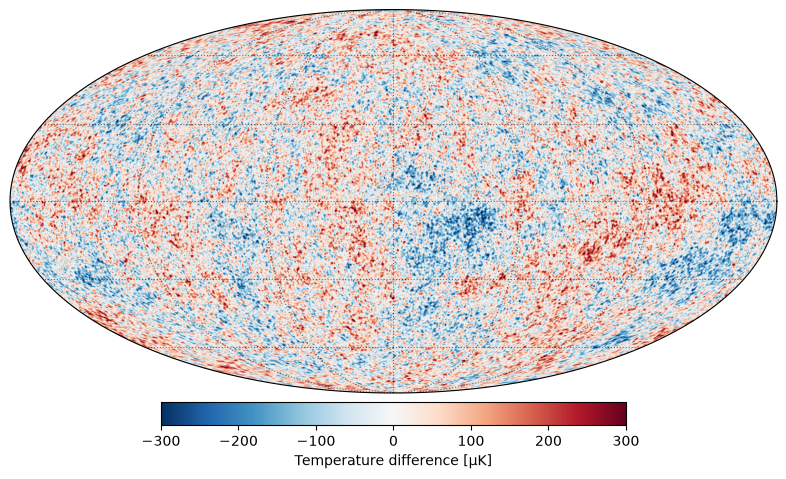

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(projection=mollweide_wcs, frame_class=EllipticalFrame)
image = ax.imshow(cmb_mollweide, origin="lower", cmap="RdBu_r", vmin=-300, vmax=300)
fig.colorbar(image, label=temperature_label, orientation="horizontal", shrink=0.5, pad=0.02)

glon, glat = ax.coords
glon.set_ticks(spacing=60 * u.deg)
glat.set_ticks(spacing=30 * u.deg)
ax.coords.grid(color="k", alpha=0.5, linestyle="dotted")
for coord in (glon, glat):
    coord.set_ticks_visible(False)
    coord.set_ticklabel_visible(False)
plt.show()

The center of the map is the direction of the center of our Galaxy, and the horizontal line through the middle is the Galactic plane, where light from the Milky Way is brightest. The map looks the same along the plane as everywhere else: separating the CMB from the light of the Milky Way removed almost all of our Galaxy from the map.

## Measure the size of the temperature fluctuations

We measure the mean and the standard deviation of the map. The standard deviation, $\sigma$, measures how far a typical pixel is from the mean.

Every pixel of the map covers the same range of RA and Dec, but that is not the same area of sky: a pixel at declination $\delta$ covers an area proportional to $\cos\delta$, so pixels near the poles cover much less sky than pixels near the equator. To count every part of the sky equally, we weight each pixel by $\cos\delta$. All the pixels in a row of the map have the same declination, so we find the declination of each row, and spread it across the columns with `np.broadcast_to`:

In [ ]:
row_dec = cmb_wcs.pixel_to_world(np.zeros(cmb_map.shape[0]), np.arange(cmb_map.shape[0])).dec
pixel_weights = np.broadcast_to(np.cos(row_dec).value[:, np.newaxis], cmb_map.shape)

mean_temperature = np.average(cmb_map, weights=pixel_weights)
std_temperature = np.sqrt(np.average((cmb_map - mean_temperature) ** 2, weights=pixel_weights))
print(f"Mean temperature difference: {mean_temperature:.2f}")
print(f"Standard deviation: {std_temperature:.1f}")

Mean temperature difference: -0.03 uK
Standard deviation: 100.6 uK


The mean is close to zero, as we expect for a map of differences from the average. We plot a histogram of the pixel values, weighting each pixel by its area again so that the histogram shows how much of the sky has each temperature. With `density=True`, the height of each bar is the fraction of the sky per μK. We mark 1, 2, and 3 standard deviations from the mean:

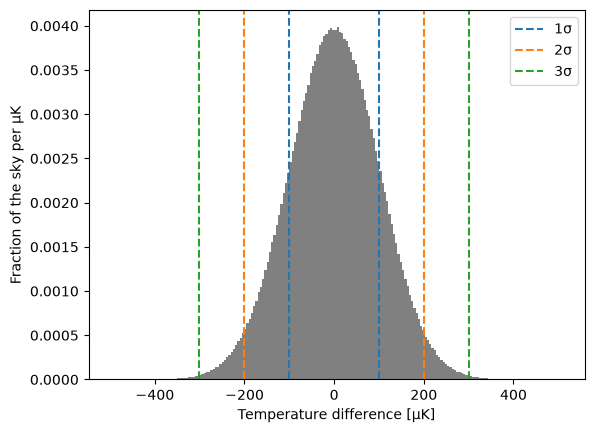

In [ ]:
fig, ax = plt.subplots()
ax.hist(cmb_map.value.ravel(), bins=200, weights=pixel_weights.ravel(), density=True, color="gray")
for n_sigma, color in zip([1, 2, 3], ["C0", "C1", "C2"]):
    for sign in [-1, 1]:
        ax.axvline(
            (mean_temperature + sign * n_sigma * std_temperature).value,
            color=color,
            linestyle="--",
            label=f"{n_sigma}σ" if sign == 1 else None,
        )
ax.set_xlabel(temperature_label)
ax.set_ylabel(f"Fraction of the sky per {cmb_map.unit:latex}")
ax.legend()
plt.show()

The histogram has the bell shape of a normal (Gaussian) distribution. For a normal distribution, 68.3% of values are within 1σ of the mean, 95.4% within 2σ, and 99.7% within 3σ. We measure the fraction of the sky in each range, again weighting each pixel by its area:

In [ ]:
for n_sigma in [1, 2, 3]:
    within = np.abs(cmb_map - mean_temperature) < n_sigma * std_temperature
    print(f"Fraction of the sky within {n_sigma}σ: {np.average(within, weights=pixel_weights):.1%}")

Fraction of the sky within 1σ: 68.3%
Fraction of the sky within 2σ: 95.4%
Fraction of the sky within 3σ: 99.7%


The fluctuations of the CMB follow a normal distribution very closely, which is one of the predictions of our best theories of the early Universe.

Finally, we compare the size of the fluctuations to the average temperature of the CMB. We use the value stored in the `Planck18` cosmology, 2.7255 K, which agrees with the 2.725 K that we measured in the [previous tutorial](1_CMB-Blackbody-Temperature.ipynb):

In [ ]:
fractional_fluctuation = (std_temperature / Planck18.Tcmb0).to(u.dimensionless_unscaled)
print(f"Fractional size of the fluctuations: {fractional_fluctuation:.1e}")

Fractional size of the fluctuations: 3.7e-05


The CMB's temperature varies across the sky by only a few parts in 100,000. These tiny differences are the imprint of slightly denser and less dense regions in the early Universe, which grew over billions of years into the galaxies and clusters of galaxies that we see today.

## Zoom in on the CMB Cold Spot

One region of the map stands out: the CMB Cold Spot, a large, unusually cold region in the southern sky, discovered in maps from NASA's WMAP satellite ([Vielva et al. 2004](https://ui.adsabs.harvard.edu/abs/2004ApJ...609...22V); [Cruz et al. 2005](https://ui.adsabs.harvard.edu/abs/2005MNRAS.356...29C)). Its position is usually given in Galactic coordinates, so we make a `SkyCoord` in the Galactic frame and transform it to the equatorial (ICRS) frame of our map:

In [ ]:
cold_spot = SkyCoord(l=209 * u.deg, b=-57 * u.deg, frame="galactic")
print(cold_spot.icrs)

<SkyCoord (ICRS): (ra, dec) in deg
    (48.29990842, -20.43730437)>


`Cutout2D` extracts a piece of an image centered on a sky position, and makes a WCS for the piece. We cut out a 40-degree square around the Cold Spot, and draw a circle of radius 5 degrees around it with `SphericalCircle`:

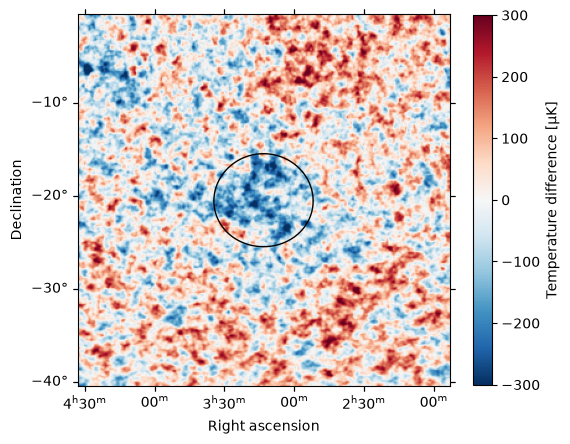

In [ ]:
cold_spot_cutout = Cutout2D(cmb_map.value, position=cold_spot, size=40 * u.deg, wcs=cmb_wcs)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection=cold_spot_cutout.wcs)
image = ax.imshow(cold_spot_cutout.data, origin="lower", cmap="RdBu_r", vmin=-300, vmax=300)
circle = SphericalCircle(
    (cold_spot.icrs.ra, cold_spot.icrs.dec),
    5 * u.deg,
    edgecolor="k",
    facecolor="none",
    transform=ax.get_transform("icrs"),
)
ax.add_patch(circle)
ax.coords[0].set_axislabel("Right ascension")
ax.coords[1].set_axislabel("Declination")
fig.colorbar(image, ax=ax, label=temperature_label, shrink=0.8)
plt.show()

To measure how cold the Cold Spot is, we find the sky position of every pixel in the cutout with `pixel_to_world`, and select the pixels within 5 degrees of the center of the Cold Spot with `separation`:

In [ ]:
ny, nx = cold_spot_cutout.shape
pixel_y, pixel_x = np.mgrid[:ny, :nx]
pixel_positions = cold_spot_cutout.wcs.pixel_to_world(pixel_x, pixel_y)

in_cold_spot = pixel_positions.separation(cold_spot) < 5 * u.deg
cold_spot_temperature = np.mean(cold_spot_cutout.data[in_cold_spot]) * cmb_map.unit
print(f"Mean temperature difference within 5 degrees of the Cold Spot: {cold_spot_temperature:.0f}")

Mean temperature difference within 5 degrees of the Cold Spot: -109 uK


On average, the region within 5 degrees of the Cold Spot is about 100 μK colder than the CMB as a whole.

In the [next tutorial](3_CMB-Standard-Ruler.ipynb), we will use the size of the hot and cold spots in this map to estimate the age of the Universe.

## Exercise

1. Measure the mean temperature difference within 5 degrees of a few other positions on the sky. How often do you find a region as cold as the Cold Spot?
2. Make a cutout centered on the Galactic center, at Galactic coordinates $l = 0°, b = 0°$. Can you tell that it lies on the Galactic plane?